## 1. Importing Needed Libraries

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Lasso
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
warnings.filterwarnings('ignore')

## 2. Loading Data

In [2]:
df = pd.read_csv('data/concrete_data.csv')

## 3. Data Overview

In [3]:
df.head(7)

,cement,blast_furnace_slag,fly_ash,water,superplasticizer,coarse_aggregate,fine_aggregate,age,concrete_compressive_strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30
5,266.0,114.0,0.0,228.0,0.0,932.0,670.0,90,47.03
6,380.0,95.0,0.0,228.0,0.0,932.0,594.0,365,43.70


In [4]:
df.info()
print(f"{'_'*50}")
print(f'Number of dublicat data: {df.duplicated().sum()}.')

<class 'pandas.DataFrame'>
RangeIndex: 1030 entries, 0 to 1029
Data columns (total 9 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   cement                         1030 non-null   float64
 1   blast_furnace_slag             1030 non-null   float64
 2   fly_ash                        1030 non-null   float64
 3   water                          1030 non-null   float64
 4   superplasticizer               1030 non-null   float64
 5   coarse_aggregate               1030 non-null   float64
 6   fine_aggregate                 1030 non-null   float64
 7   age                            1030 non-null   int64  
 8   concrete_compressive_strength  1030 non-null   float64
dtypes: float64(8), int64(1)
memory usage: 72.6 KB
__________________________________________________
Number of dublicat data: 25.


In [5]:
df.describe()

,cement,blast_furnace_slag,fly_ash,water,superplasticizer,coarse_aggregate,fine_aggregate,age,concrete_compressive_strength
count,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000
mean,281.167864,73.895825,54.188350,181.567282,6.204660,972.918932,773.580485,45.662136,35.817961
std,104.506364,86.279342,63.997004,21.354219,5.973841,77.753954,80.175980,63.169912,16.705742
min,102.000000,0.000000,0.000000,121.800000,0.000000,801.000000,594.000000,1.000000,2.330000
25%,192.375000,0.000000,0.000000,164.900000,0.000000,932.000000,730.950000,7.000000,23.710000
50%,272.900000,22.000000,0.000000,185.000000,6.400000,968.000000,779.500000,28.000000,34.445000
75%,350.000000,142.950000,118.300000,192.000000,10.200000,1029.400000,824.000000,56.000000,46.135000
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000,82.600000


In [6]:
df.corr()['concrete_compressive_strength']

cement                           0.497832
blast_furnace_slag               0.134829
fly_ash                         -0.105755
water                           -0.289633
superplasticizer                 0.366079
coarse_aggregate                -0.164935
fine_aggregate                  -0.167241
age                              0.328873
concrete_compressive_strength    1.000000
Name: concrete_compressive_strength, dtype: float64

## 4. Organizing Data

In [7]:
df = df.drop_duplicates()
print(f'Number of dublicat data now: {df.duplicated().sum()}.')

Number of dublicat data now: 0.


In [8]:
df['age_log'] = np.log1p(df['age'])
df = df.drop('age', axis=1)

Q1 = df['age_log'].quantile(0.25)
Q3 = df['age_log'].quantile(0.75)
IQR = Q3 - Q1
df_filtered = df[(df['age_log'] >= Q1 - 1.5*IQR) & (df['age_log'] <= Q3 + 1.5*IQR)]

## 5. Visualizing the Data

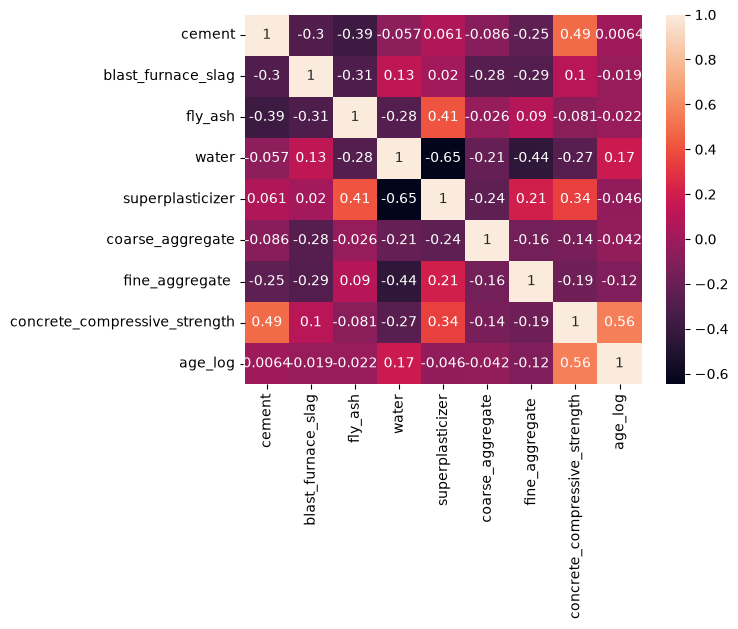

In [9]:
sns.heatmap(df.corr(), annot=True)
plt.savefig('results/heatmap.png', dpi=200, bbox_inches='tight')
plt.show()

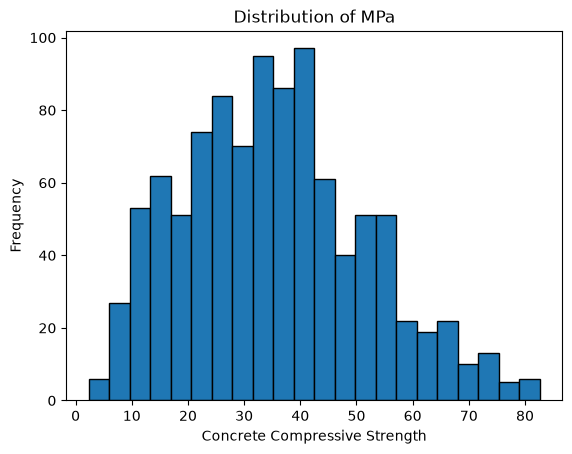

In [10]:
plt.hist(df['concrete_compressive_strength'], bins=22, edgecolor='black')
plt.title("Distribution of MPa")
plt.xlabel("Concrete Compressive Strength")
plt.ylabel("Frequency")
plt.savefig('results/dist-of-mpa.png', dpi=200, bbox_inches='tight')
plt.show()

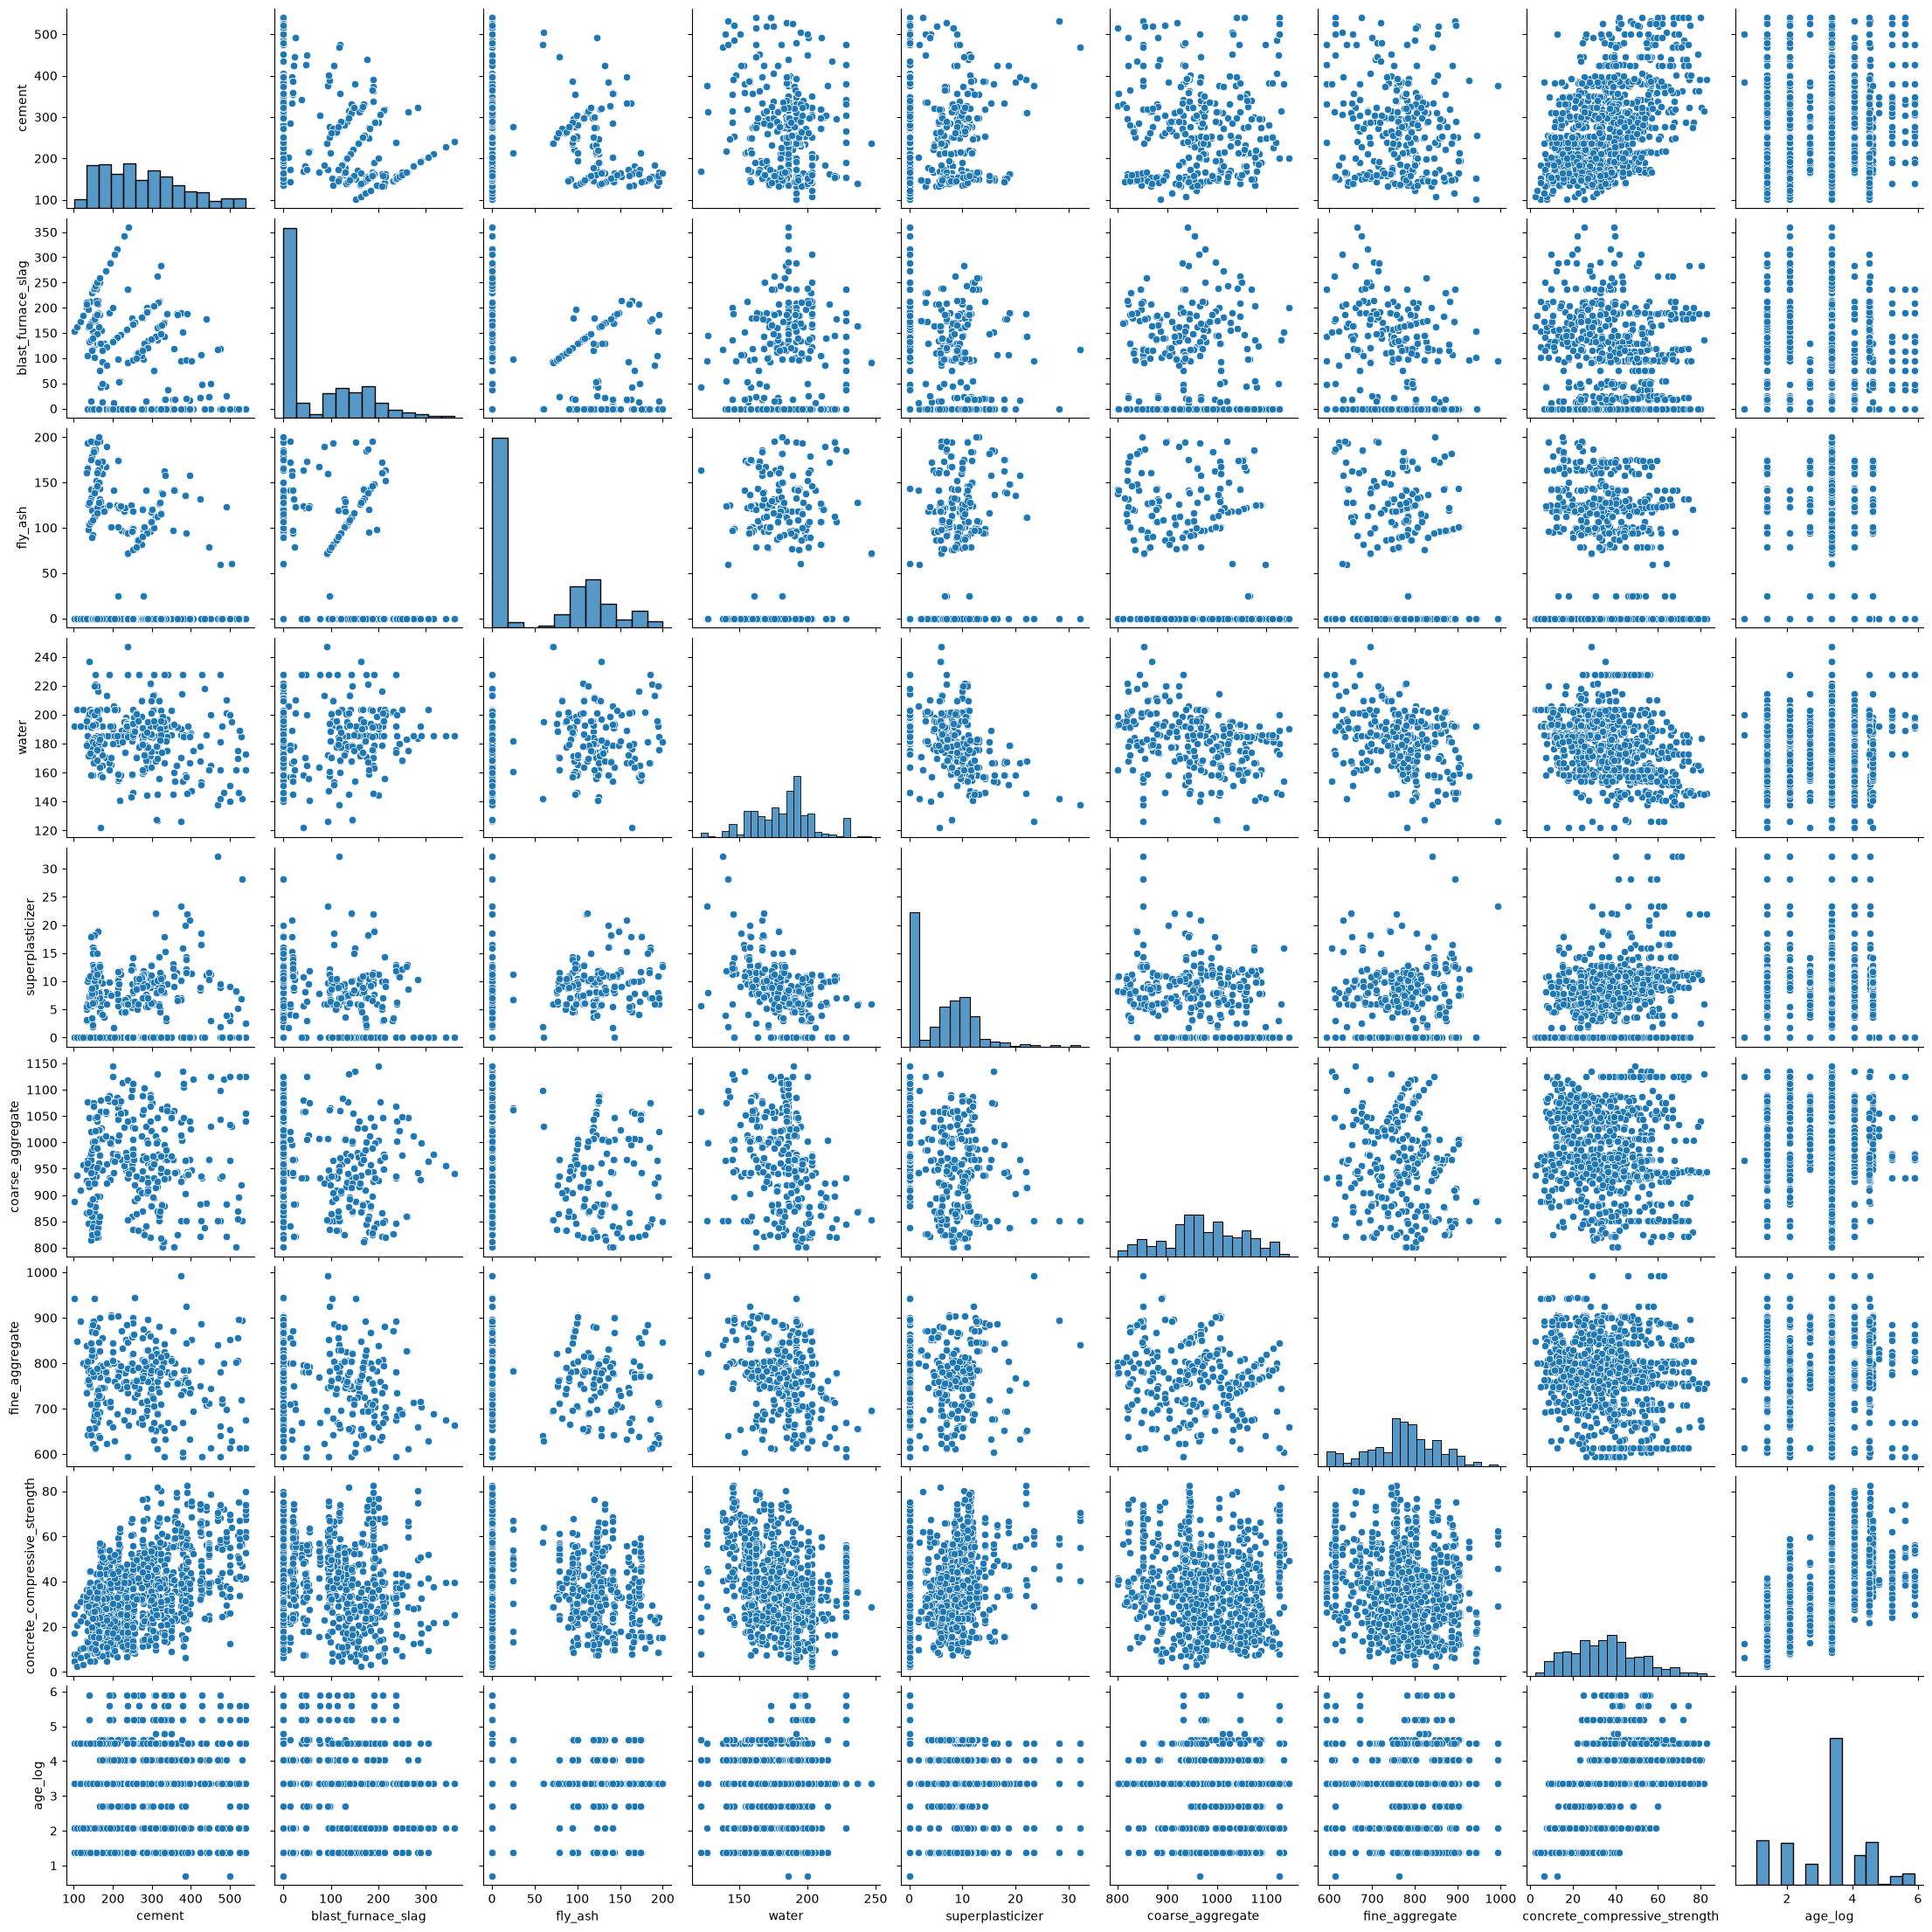

In [11]:
sns.pairplot(df)
plt.savefig('results/pair_plot.png', dpi=200, bbox_inches='tight')
plt.show()

## 6. Train/Test Split + Model Pipeline
Stratified 80/20 split, scaler + Ridge pipeline, GridSearchCV tuning C via 10-fold CV.

In [12]:
X = df_filtered.drop('concrete_compressive_strength', axis=1)
y = df_filtered['concrete_compressive_strength']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=42)

pipe = Pipeline([
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('scaler', StandardScaler()),
    ('model', Lasso(alpha=1.0, random_state=42, max_iter=10000))
])

param_grid = {'model__alpha' : [1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1, 10, 100, 1000],
              'poly__degree': [1, 2, 3, 4, 5, 6]
              }
grid = GridSearchCV(pipe, param_grid, cv = 10, scoring='r2')

## 7. Model Training

In [13]:
grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__alpha': [1e-05, 0.0001, ...], 'poly__degree': [1, 2, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",10
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of in

## 8. Evaluation

In [14]:
preds = grid.predict(X_test)
mae = mean_absolute_error(y_test, preds)
mse = mean_squared_error(y_test, preds)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, preds)

print(f"Mean Absolute Error: {mae:.3f}")
print(f"{'_'*50}")
print(f"Mean Squared Error: {mse:.3f}")
print(f"{'_'*50}")
print(f"Square Root of Mean Squared Error: {rmse:.3f}")
print(f"{'_'*50}")
print(f"R2 Score: {r2:.3f}")

Mean Absolute Error: 3.529
__________________________________________________
Mean Squared Error: 26.738
__________________________________________________
Square Root of Mean Squared Error: 5.171
__________________________________________________
R2 Score: 0.910


In [15]:
print(f'Best alpha chosen by GridSearchCV: {grid.best_params_['model__alpha']}')
print(f'{'_'*40}')
print(f'Best polynomial degree chosen by GridSearchCV: {grid.best_params_['poly__degree']}')
print(f'{'_'*40}')
print(f'R2 Train Score:{grid.score(X_train, y_train)*100:.2f}%')
print(f'{'_'*40}')
print(f'R2 Test Score:{grid.score(X_test, y_test)*100:.2f}%')

Best alpha chosen by GridSearchCV: 0.01
________________________________________
Best polynomial degree chosen by GridSearchCV: 6
________________________________________
R2 Train Score:93.69%
________________________________________
R2 Test Score:91.04%
